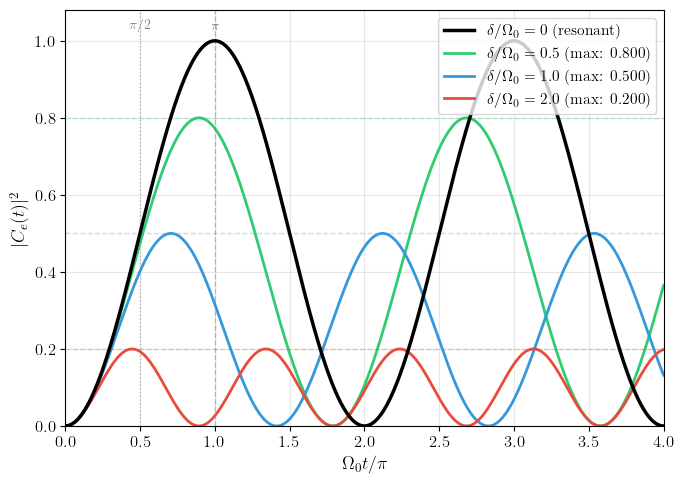

In [7]:
#| fig-align: center
#| fig-alt: |
#|   Rabi oscillations showing excited state population versus time. The resonant
#|   case (black) oscillates between 0 and 1. Off-resonant cases (green, blue, red)
#|   show faster oscillations with incomplete population transfer that decreases
#|   with increasing detuning.

import numpy as np
import matplotlib.pyplot as plt

# --- Set up plot styling ---
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12



# Time array in units of Omega_0
t_Omega0 = np.linspace(0, 4*np.pi, 1000)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Resonant case: delta = 0
# |C_e(t)|^2 = sin^2(Omega_0 * t / 2)
Pe_resonant = np.sin(t_Omega0 / 2)**2
ax.plot(t_Omega0 / np.pi, Pe_resonant, 'k-', linewidth=2.5, 
        label='$\\delta/\\Omega_0=0$ (resonant)', zorder=3)

# Off-resonant cases with different detunings
# Generalized Rabi frequency: Omega = sqrt(delta^2 + |Omega_0|^2)
# |C_e(t)|^2 = (|Omega_0|^2 / Omega^2) * sin^2(Omega * t / 2)

detunings = [0.5, 1.0, 2.0]  # delta in units of Omega_0
colors = ['#2ecc71', '#3498db', '#e74c3c']

for i, delta in enumerate(detunings):
    Omega = np.sqrt(delta**2 + 1)  # Omega_0 = 1 in our units
    Pe_off = (1 / Omega**2) * np.sin(Omega * t_Omega0 / 2)**2
    max_Pe = 1 / Omega**2
    
    ax.plot(t_Omega0 / np.pi, Pe_off, color=colors[i], linewidth=2, 
            label=f'$\\delta/\\Omega_0={delta}$ (max: {max_Pe:.3f})', zorder=2)
    ax.axhline(y=max_Pe, color=colors[i], linestyle='--', alpha=0.3, linewidth=1)

# Mark special pulse areas
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.text(0.5, 1.02, '$\\pi/2$', ha='center', va='bottom', fontsize=10, color='gray')
ax.text(1.0, 1.02, '$\\pi$', ha='center', va='bottom', fontsize=10, color='gray')

ax.set_xlabel('$\\Omega_0 t / \\pi$', fontsize=13)
ax.set_ylabel('$|C_e(t)|^2$', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(-0.0, 1.08)
ax.set_xlim(0, 4)

plt.tight_layout()
plt.show()


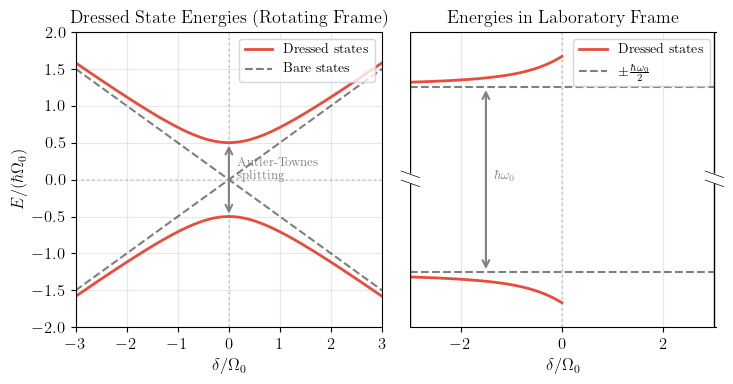

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# --- Set up plot styling ---
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12



# Detuning range in units of Omega_0
delta_range = np.linspace(-3, 3, 500)

offset = 0.001
delta_rangen = np.linspace(-3, -offset, 250)
delta_rangep = np.linspace(offset, 3, 250)

# Rabi frequency (we'll show multiple values)
Omega0_values = [1]
colors = ['#e74c3c']
labels = [r'Dressed states']

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 4))

# ============= LEFT PLOT: ROTATING FRAME (DRESSED STATES) =============
ax1.set_title('Dressed State Energies (Rotating Frame)', fontsize=13, fontweight='bold')

# Plot uncoupled (bare) states as dashed lines

# Plot dressed states for different Omega_0 values
for i, Omega0 in enumerate(Omega0_values):
    # Dressed state energies: E_± = ±(1/2)√(δ² + |Ω₀|²)
    Omega = Omega0*np.sqrt(delta_range**2 + 1)
    E_plus = 0.5 * Omega/Omega0
    E_minus = -0.5 * Omega
    
    ax1.plot(delta_range, E_plus, color=colors[i], linewidth=2, label=labels[i])
    ax1.plot(delta_range, E_minus, color=colors[i], linewidth=2)

ax1.plot(delta_range, -delta_range/2, 'k--', linewidth=1.5, alpha=0.5, label='Bare states')
ax1.plot(delta_range, delta_range/2, 'k--', linewidth=1.5, alpha=0.5)

ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.3)
ax1.set_xlabel('$\\delta / \\Omega_0$', fontsize=12)
ax1.set_ylabel('$E / (\\hbar \\Omega_0)$', fontsize=12)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-3, 3)
ax1.set_ylim(-2, 2)

# Add annotation for avoided crossing
ax1.annotate('', xy=(0, .5), xytext=(0, -.5),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax1.text(0.15, 0, 'Autler-Townes\nsplitting', fontsize=9, color='gray')

# ============= RIGHT PLOT: LABORATORY FRAME =============
ax2.set_title('Energies in Laboratory Frame', fontsize=13, fontweight='bold')

# For the lab frame, we add ±ω₀/2 and use sgn(δ) for the shifts
# We'll set ω₀ = 10 in units of Omega_0 for visualization
omega_0 = 3

for i, Omega0 in enumerate(Omega0_values):
    Omega = np.sqrt(delta_rangen**2 + Omega0**2)
    sgn_delta = np.sign(delta_rangen)
    # E_e = (ω₀/2) + (δ/2) - sgn(δ)·√(δ² + |Ω₀|²)/2
    E_e = 0.5*omega_0 + 0.5*delta_rangen - 0.5*sgn_delta*Omega    
    # E_g = -(ω₀/2) - (δ/2) + sgn(δ)·√(δ² + |Ω₀|²)/2
    E_g = -0.5*omega_0 - 0.5*delta_rangen + 0.5*sgn_delta*Omega
    ax2.plot(delta_rangen, E_e, color=colors[0], linewidth=2, label=labels[0])
    ax2.plot(delta_rangen, E_g, color=colors[0], linewidth=2)

    Omega = np.sqrt(delta_rangep**2 + Omega0**2)
    sgn_delta = np.sign(delta_rangep)
    # E_e = (ω₀/2) + (δ/2) - sgn(δ)·√(δ² + |Ω₀|²)/2
    E_e = 0.5*omega_0 + 0.5*delta_rangep - 0.5*sgn_delta*Omega    
    # E_g = -(ω₀/2) - (δ/2) + sgn(δ)·√(δ² + |Ω₀|²)/2
    E_g = -0.5*omega_0 - 0.5*delta_rangep + 0.5*sgn_delta*Omega
    ax2.plot(delta_rangep, E_e, color=colors[0], linewidth=2)
    ax2.plot(delta_rangep, E_g, color=colors[0], linewidth=2)

# Plot bare states (without coupling)
E_e_bare = 0.5*omega_0 + 0.*delta_range
E_g_bare = -0.5*omega_0 - 0.*delta_range
ax2.plot(delta_range, E_e_bare, 'k--', linewidth=1.5, alpha=0.5, label=r'$\pm\frac{\hbar\omega_0}{2}$')
ax2.plot(delta_range, E_g_bare, 'k--', linewidth=1.5, alpha=0.5)

#ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.3)
ax2.set_xlabel('$\\delta / \\Omega_0$', fontsize=12)
#ax2.set_ylabel('$E / (\\hbar \\Omega_0)$', fontsize=12)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_yticks([])
ax2.set_xlim(-3, 3.05)
ax2.set_ylim(-2.4, 2.4)


# Add annotation for avoided crossing
arrow_xpos = -1.5
ax2.annotate('', xy=(arrow_xpos, -omega_0/2), xytext=(arrow_xpos, omega_0/2),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax2.text(arrow_xpos+0.15, 0, r'$\hbar\omega_0$', fontsize=9, color='gray')


# --- Add the fake break here ---
# Coordinates for the rectangle to hide the middle section
break_y_min = -0.1
break_y_max = 0.1
#break_x_min = -0.1 # x position of left spine
#break_x_max = 0.3 # Width of the break patch, set slightly larger than the spine

# Add a white rectangle to hide the axis spine in the break region
#rect = Rectangle((break_x_min, break_y_min), break_x_max, break_y_max - break_y_min,
#                 facecolor='white', edgecolor='white', zorder=3, transform=ax.transData)
#ax.add_patch(rect)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.vlines(ax2.get_xlim()[0],ax2.get_ylim()[0], break_y_min+0.05, color='black', linewidth=1)
ax2.vlines(ax2.get_xlim()[0],ax2.get_ylim()[1], break_y_max, color='k', linewidth=1)
ax2.vlines(ax2.get_xlim()[1]-0.05,ax2.get_ylim()[0], break_y_min+0.05, color='k', linewidth=1)
ax2.vlines(ax2.get_xlim()[1]-0.05,ax2.get_ylim()[1], break_y_max, color='black', linewidth=1)
# Add the break symbol "//"
ax2.text(ax2.get_xlim()[0], (break_y_min + break_y_max) / 2+0.03, r'$//$',
        ha='center', va='center', fontsize=14, color='black', rotation=90)
ax2.text(ax2.get_xlim()[1]-0.05, (break_y_min + break_y_max) / 2+0.03, r'$//$',
        ha='center', va='center', fontsize=14, color='black', rotation=90)





plt.tight_layout()
plt.show()


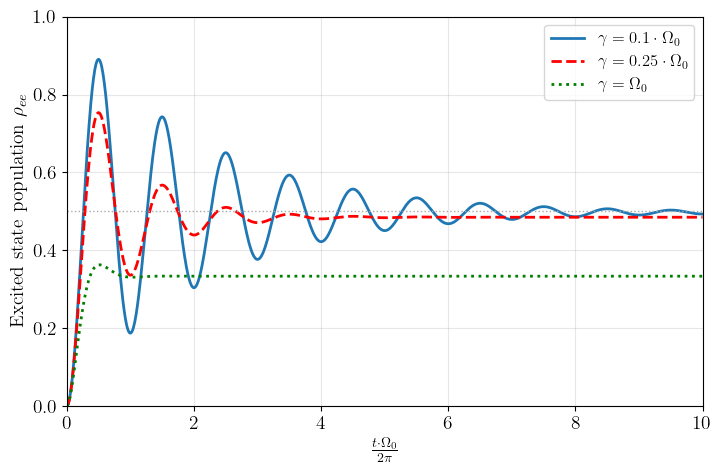

In [80]:
"""
Damped Rabi Oscillations - Python translation
Original MATLAB code from:
https://www.mathworks.com/matlabcentral/fileexchange/52305-numerical-solution-to-optical-bloch-equation-for-a-two-level-atom-using-runge-kutta-method
Author: Sathyanarayan Rao

Copyright (c) 2015, Sathyanarayan Narasimhan
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution
THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT OWNER OR CONTRIBUTORS BE LIABLE
FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.
"""
import numpy as np
import matplotlib.pyplot as plt

# --- Set up plot styling ---
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 16


# Function definitions
def drho11(t, r12, r21, r22, gam, Omega_rabi, delta):
    """Calculate derivative of rho11"""
    return (1j * 0.5 * np.conj(Omega_rabi) * np.exp(-1j * delta * t) * r12 - 
            1j * 0.5 * Omega_rabi * np.exp(1j * delta * t) * r21 + 
            gam * r22)

def drho12(t, r11, r12, r22, gam, Omega_rabi, delta):
    """Calculate derivative of rho12"""
    return (1j * 0.5 * Omega_rabi * np.exp(1j * delta * t) * (r11 - r22) - 
            0.5 * gam * r12)

def drho21(t, r11, r21, r22, gam, Omega_rabi, delta):
    return (-1j * 0.5 * np.conj(Omega_rabi) * np.exp(-1j * delta * t) * (r11 - r22) - 
            0.5 * gam * r21)

def drho22(t, r12, r21, r22, gam, Omega_rabi, delta):
    """Calculate derivative of rho22"""
    return (-1j * 0.5 * np.conj(Omega_rabi) * np.exp(-1j * delta * t) * r12 + 
            1j * 0.5 * Omega_rabi * np.exp(1j * delta * t) * r21 - 
            gam * r22)

# Main code
# Optical Bloch Equation for a two level atom

Omega_rabi = 2 * np.pi * 10 * 1e6  # Rabi frequency 2pi*10 MHz
delta = Omega_rabi  # Detuning frequency
gamma = Omega_rabi  # linewidth



# Parameters
N = 1000  # number of time grid points
t = np.linspace(0, 1e-6, N)  # time array in seconds
dt = t[1] - t[0]  # step size in time


def density_me(Omega_rabi, delta, gamma):
   # Initial conditions
   rho11 = np.ones(N, dtype=complex)
   rho22 = np.zeros(N, dtype=complex)
   rho12 = np.zeros(N, dtype=complex)
   rho21 = np.zeros(N, dtype=complex)


   # Runge-Kutta 4th order
   for i in range(1, N):
       # k1, l1, m1, n1
       k1 = drho22(t[i-1], rho12[i-1], rho21[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
       l1 = drho11(t[i-1], rho12[i-1], rho21[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
       m1 = drho12(t[i-1], rho11[i-1], rho12[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
       n1 = drho21(t[i-1], rho11[i-1], rho21[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
    
       # k2, l2, m2, n2
       k2 = drho22(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m1, rho21[i-1] + 0.5*n1, 
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
       l2 = drho11(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m1, rho21[i-1] + 0.5*n1, 
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
       m2 = drho12(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l1, rho12[i-1] + 0.5*m1, 
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
       n2 = drho21(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l1, rho21[i-1] + 0.5*n1,
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
    
       # k3, l3, m3, n3
       k3 = drho22(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m2, rho21[i-1] + 0.5*n2, 
                   rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt
       l3 = drho11(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m2, rho21[i-1] + 0.5*n2, 
                   rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt
       m3 = drho12(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l2, rho12[i-1] + 0.5*m2, 
                   rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt
       n3 = drho21(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l2, rho21[i-1] + 0.5*n2,
               rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt

       # k4, l4, m4, n4
       k4 = drho22(t[i-1] + dt, rho12[i-1] + m3, rho21[i-1] + n3, 
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
       l4 = drho11(t[i-1] + dt, rho12[i-1] + m3, rho21[i-1] + n3, 
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
       m4 = drho12(t[i-1] + dt, rho11[i-1] + l3, rho12[i-1] + m3, 
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
       n4 = drho21(t[i-1] + dt, rho11[i-1] + l3, rho21[i-1] + n3,
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
    
       # Update
       rho22[i] = rho22[i-1] + (k1 + 2*(k2 + k3) + k4) / 6
       rho11[i] = rho11[i-1] + (l1 + 2*(l2 + l3) + l4) / 6
       rho12[i] = rho12[i-1] + (m1 + 2*(m2 + m3) + m4) / 6
       rho21[i] = rho21[i-1] + (n1 + 2*(n2 + n3) + n4) / 6
   return rho11, rho12, rho21, rho22

a, b, c, rho22_1 = density_me(Omega_rabi, 0*delta, 0.1*gamma)
a, b, c, rho22_2 = density_me(Omega_rabi, 0*delta, 0.25*gamma)
a, b, c, rho22_3 = density_me(Omega_rabi, 0*delta, gamma)


# Plotting
plt.figure(figsize=(7.5, 5))
plt.plot(t*Omega_rabi/(2*np.pi), np.real(rho22_1), linewidth=2, label=r'$\gamma=0.1\cdot\Omega_0$')
plt.plot(t*Omega_rabi/(2*np.pi), np.real(rho22_2), 'r--', linewidth=2, label=r'$\gamma=0.25\cdot\Omega_0$')
plt.plot(t*Omega_rabi/(2*np.pi), np.real(rho22_3), 'g:', linewidth=2, label=r'$\gamma=\Omega_0$')
#plt.plot(t, np.real(rho11), 'k', linewidth=2, label=r'$\rho_{11}$')
#plt.plot(t, np.abs(rho12), 'r', linewidth=2, label=r'$|\rho_{12}|$')
#plt.plot(t, np.abs(rho21), 'g', linewidth=2, label=r'$|\rho_{21}|$')
plt.axhline(0.5, color='darkgrey', linestyle=':', linewidth=1)
plt.xlabel(r'$\frac{t\cdot \Omega_0}{2\pi}$', fontsize=14)
plt.ylabel(r'Excited state population $\rho_{ee}$', fontsize=14)
plt.xlim([0, t[-1]*Omega_rabi/(2*np.pi)])
plt.ylim([0, 1])
plt.tick_params(labelsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

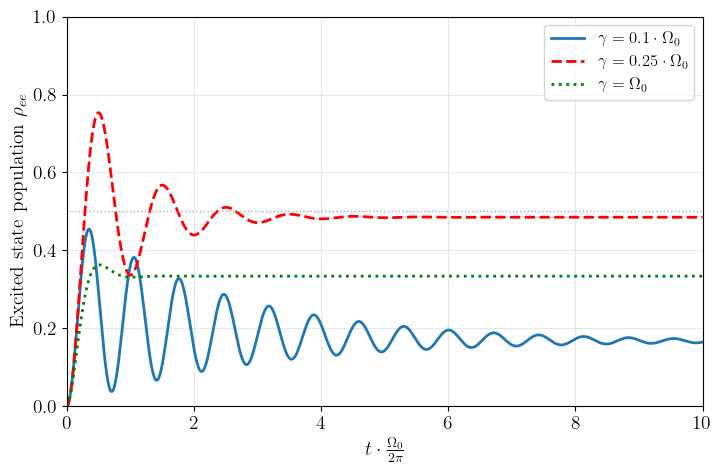

In [78]:
"""
Damped Rabi Oscillations - Rotating Frame
Based on Python translation of MATLAB code from:
https://www.mathworks.com/matlabcentral/fileexchange/52305-numerical-solution-to-optical-bloch-equation-for-a-two-level-atom-using-runge-kutta-method
Author: Sathyanarayan Rao

Copyright (c) 2015, Sathyanarayan Narasimhan
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution
THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT OWNER OR CONTRIBUTORS BE LIABLE
FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.
"""
import numpy as np
import matplotlib.pyplot as plt

# --- Set up plot styling ---
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 16


# Function definitions - ROTATING FRAME
def drho11(t, r12, r21, r22, gam, Omega_rabi, delta):
    """Calculate derivative of rho11 - rotating frame"""
    return (1j * 0.5 * np.conj(Omega_rabi) * r12 - 
            1j * 0.5 * Omega_rabi * r21 + 
            gam * r22)

def drho12(t, r11, r12, r22, gam, Omega_rabi, delta):
    """Calculate derivative of rho12 - rotating frame"""
    return (1j * 0.5 * Omega_rabi * (r11 - r22) - 
            1j * delta * r12 -
            0.5 * gam * r12)

def drho21(t, r11, r21, r22, gam, Omega_rabi, delta):
    """Calculate derivative of rho21 - rotating frame"""
    return (-1j * 0.5 * np.conj(Omega_rabi) * (r11 - r22) + 
            1j * delta * r21 -
            0.5 * gam * r21)

def drho22(t, r12, r21, r22, gam, Omega_rabi, delta):
    """Calculate derivative of rho22 - rotating frame"""
    return (-1j * 0.5 * np.conj(Omega_rabi) * r12 + 
            1j * 0.5 * Omega_rabi * r21 - 
            gam * r22)

# Main code
# Optical Bloch Equation for a two level atom

Omega_rabi = 2 * np.pi * 10 * 1e6  # Rabi frequency 2pi*10 MHz
delta = Omega_rabi  # Detuning frequency
gamma = Omega_rabi  # linewidth



# Parameters
N = 1000  # number of time grid points
t = np.linspace(0, 1e-6, N)  # time array in seconds
dt = t[1] - t[0]  # step size in time


def density_me(Omega_rabi, delta, gamma):
   # Initial conditions
   rho11 = np.ones(N, dtype=complex)
   rho22 = np.zeros(N, dtype=complex)
   rho12 = np.zeros(N, dtype=complex)
   rho21 = np.zeros(N, dtype=complex)


   # Runge-Kutta 4th order
   for i in range(1, N):
       # k1, l1, m1, n1
       k1 = drho22(t[i-1], rho12[i-1], rho21[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
       l1 = drho11(t[i-1], rho12[i-1], rho21[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
       m1 = drho12(t[i-1], rho11[i-1], rho12[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
       n1 = drho21(t[i-1], rho11[i-1], rho21[i-1], rho22[i-1], gamma, Omega_rabi, delta) * dt
    
       # k2, l2, m2, n2
       k2 = drho22(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m1, rho21[i-1] + 0.5*n1, 
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
       l2 = drho11(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m1, rho21[i-1] + 0.5*n1, 
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
       m2 = drho12(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l1, rho12[i-1] + 0.5*m1, 
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
       n2 = drho21(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l1, rho21[i-1] + 0.5*n1,
                   rho22[i-1] + 0.5*k1, gamma, Omega_rabi, delta) * dt
    
       # k3, l3, m3, n3
       k3 = drho22(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m2, rho21[i-1] + 0.5*n2, 
                   rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt
       l3 = drho11(t[i-1] + 0.5*dt, rho12[i-1] + 0.5*m2, rho21[i-1] + 0.5*n2, 
                   rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt
       m3 = drho12(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l2, rho12[i-1] + 0.5*m2, 
                   rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt
       n3 = drho21(t[i-1] + 0.5*dt, rho11[i-1] + 0.5*l2, rho21[i-1] + 0.5*n2,
               rho22[i-1] + 0.5*k2, gamma, Omega_rabi, delta) * dt

       # k4, l4, m4, n4
       k4 = drho22(t[i-1] + dt, rho12[i-1] + m3, rho21[i-1] + n3, 
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
       l4 = drho11(t[i-1] + dt, rho12[i-1] + m3, rho21[i-1] + n3, 
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
       m4 = drho12(t[i-1] + dt, rho11[i-1] + l3, rho12[i-1] + m3, 
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
       n4 = drho21(t[i-1] + dt, rho11[i-1] + l3, rho21[i-1] + n3,
                   rho22[i-1] + k3, gamma, Omega_rabi, delta) * dt
    
       # Update
       rho22[i] = rho22[i-1] + (k1 + 2*(k2 + k3) + k4) / 6
       rho11[i] = rho11[i-1] + (l1 + 2*(l2 + l3) + l4) / 6
       rho12[i] = rho12[i-1] + (m1 + 2*(m2 + m3) + m4) / 6
       rho21[i] = rho21[i-1] + (n1 + 2*(n2 + n3) + n4) / 6
   return rho11, rho12, rho21, rho22

a, b, c, rho22_1 = density_me(Omega_rabi, 1*delta, 0.1*gamma)
a, b, c, rho22_2 = density_me(Omega_rabi, 0*delta, 0.25*gamma)
a, b, c, rho22_3 = density_me(Omega_rabi, 0*delta, gamma)


# Plotting
plt.figure(figsize=(7.5, 5))
plt.plot(t*Omega_rabi/(2*np.pi), np.real(rho22_1), linewidth=2, label=r'$\gamma=0.1\cdot\Omega_0$')
plt.plot(t*Omega_rabi/(2*np.pi), np.real(rho22_2), 'r--', linewidth=2, label=r'$\gamma=0.25\cdot\Omega_0$')
plt.plot(t*Omega_rabi/(2*np.pi), np.real(rho22_3), 'g:', linewidth=2, label=r'$\gamma=\Omega_0$')
plt.axhline(0.5, color='darkgrey', linestyle=':', linewidth=1)
plt.xlabel(r'$t\cdot \frac{\Omega_0}{2\pi}$', fontsize=14)
plt.ylabel(r'Excited state population $\rho_{ee}$', fontsize=14)
plt.xlim([0, t[-1]*Omega_rabi/(2*np.pi)])
plt.ylim([0, 1])
plt.tick_params(labelsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()